## Ejercicio 1 — El reporte semanal para el jefe de planta

Tu jefe te escribe: *"Necesito ver cómo viene la producción esta semana, envíame algo simple que pueda mirar en 5 segundos."*

Crea un gráfico de líneas mostrando la producción a lo largo del dataset. Ponle título, nombre a los ejes, y asegúrate de que el eje Y no sea engañoso sobre el tamaño real de las variaciones.

**Pistas:**
- Piensa si conviene que el eje Y comience en 0 o no, según lo que quieras comunicarle a tu jefe.
- `ax.set_xlabel()`, `ax.set_ylabel()`, `ax.set_title()`.


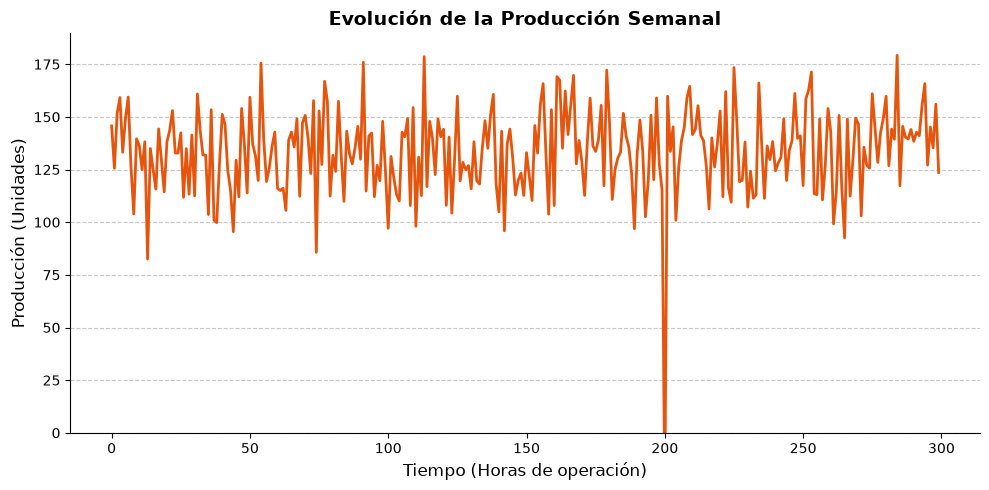

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("sensores.csv")


# 2. Tu código del gráfico
fig, ax = plt.subplots(figsize=(10, 5))

# Trazar la línea de producción
ax.plot(df.index, df["produccion"], color="#e6550d", linewidth=2)

# Configurar títulos y etiquetas claras
ax.set_title("Evolución de la Producción Semanal", fontsize=14, fontweight="bold")
ax.set_xlabel("Tiempo (Horas de operación)", fontsize=12)
ax.set_ylabel("Producción (Unidades)", fontsize=12)

# Forzar que el eje Y comience en 0
ax.set_ylim(ymin=0) 

# Agregar una cuadrícula suave
ax.grid(axis="y", linestyle="--", alpha=0.7)

# Quitar los bordes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()



Un compañero de mantenimiento te dice: *"Creo que un sensor de temperatura funcionó mal en algún momento, pero no sé cuándo. ¿Me puedes confirmar?"*

Grafica la temperatura a lo largo de todo el dataset y comenta en qué zona aproximada del gráfico ves algo raro. No hace falta calcular nada — solo observar.

**Pistas:**
- Un gráfico de líneas te muestra los saltos que no tienen continuidad con lo anterior ni con lo siguiente.
- Si el salto es difícil de ver por la escala del eje Y, prueba ajustando `set_ylim()`.

---

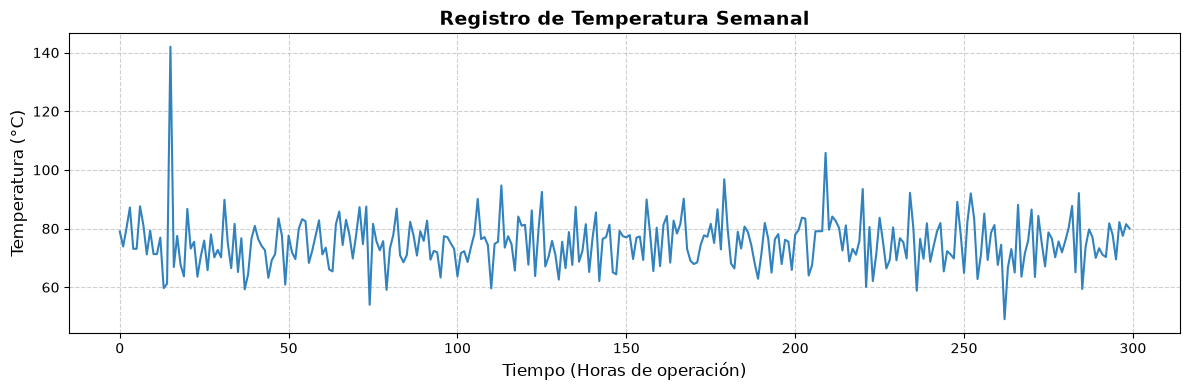

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["temperatura"], color="#3182bd", linewidth=1.5)

ax.set_title("Registro de Temperatura Semanal", fontsize=14, fontweight="bold")
ax.set_xlabel("Tiempo (Horas de operación)", fontsize=12)
ax.set_ylabel("Temperatura (°C)", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()  

## Ejercicio 3 — Comparar turnos para el área de RRHH

RRHH quiere saber si conviene reforzar personal en algún turno según el consumo eléctrico que maneja cada uno (más consumo = más carga operativa).

1. Crea una columna `turno` a partir de la hora del día (puedes usar `df.index % 24` y `pd.cut()`, como en la clase).
2. Calculá el consumo promedio por turno.
3. Grafícalo en barras, ordenado de mayor a menor.

**Pistas:**
- Recuerda: el eje Y de las barras siempre comienza en 0.
- `.groupby("turno")["consumo_kwh"].mean().sort_values(ascending=False)`


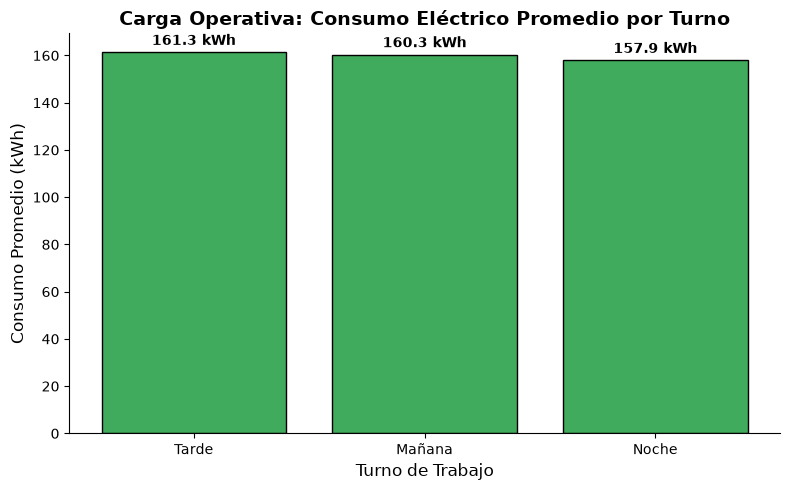

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Crear la columna 'turno'
# Extraemos la hora del día usando el módulo 24 sobre el índice
df["hora_del_dia"] = df.index % 24

# Discretizamos las horas en tres turnos usando pd.cut
df["turno"] = pd.cut(df["hora_del_dia"], 
                     bins=[-1, 7, 15, 23], 
                     labels=["Noche", "Mañana", "Tarde"])

# 2. Calcular el consumo promedio por turno ordenado de mayor a menor
# Usamos observed=True recomendado en versiones recientes de Pandas para datos categóricos
consumo_por_turno = df.groupby("turno", observed=True)["consumo_kwh"].mean().sort_values(ascending=False)

# 3. Graficar en barras
fig, ax = plt.subplots(figsize=(8, 5))

# Creamos el gráfico de barras
barras = ax.bar(consumo_por_turno.index, consumo_por_turno.values, color="#41ab5d", edgecolor="black")

# Configuración de estética y etiquetas
ax.set_title("Carga Operativa: Consumo Eléctrico Promedio por Turno", fontsize=14, fontweight="bold")
ax.set_xlabel("Turno de Trabajo", fontsize=12)
ax.set_ylabel("Consumo Promedio (kWh)", fontsize=12)

# Un toque profesional: Agregar el valor numérico exacto arriba de cada barra
for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f} kWh',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 3),  # 3 puntos de separación hacia arriba
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight="bold")

# Limpiamos el gráfico ocultando bordes innecesarios
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Ejercicio 4 — Barras agrupadas: primera mitad del período vs. segunda mitad

Tu jefe ahora pregunta: *"¿La segunda mitad del período que registramos consumió más o menos que la primera, turno por turno?"*

Divide el dataset en dos mitades (usando el índice), calcula el consumo promedio por turno en cada mitad, y muéstralo con barras agrupadas (una al lado de la otra) para poder comparar turno por turno.

**Pistas:**
- `df.iloc[:150]` y `df.iloc[150:]` para partir el dataset.
- Repasa el ejemplo de barras agrupadas con `x - ancho/2` y `x + ancho/2` que vimos en una clase anterior de gráficos.


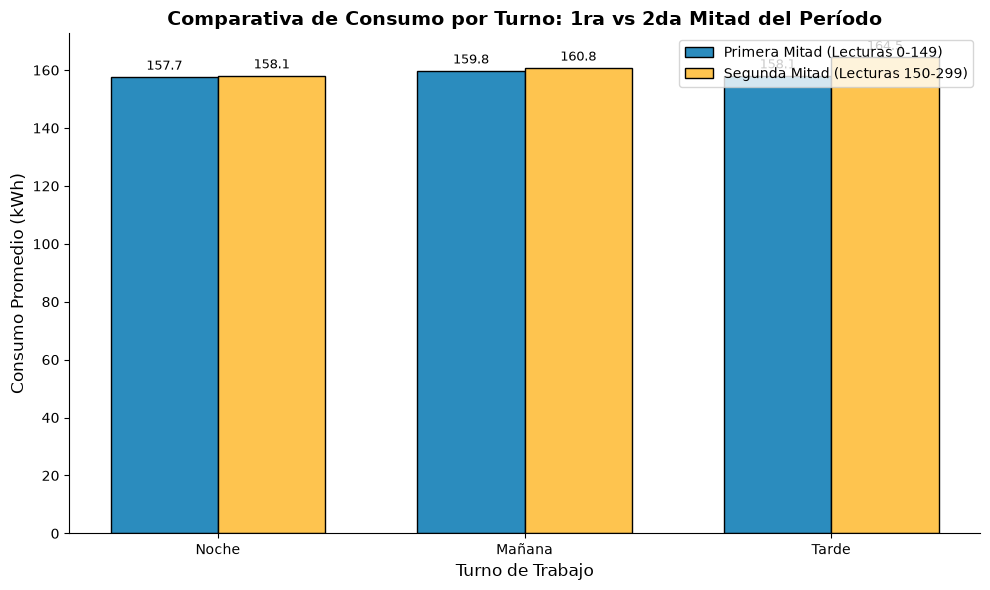

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # Asumiendo que plt ya está importado correctamente como matplotlib.pyplot

# 1. Dividir el dataset en dos mitades
mitad_1 = df.iloc[:150]
mitad_2 = df.iloc[150:]

# 2. Calcular el consumo promedio por turno para cada mitad
# Nos aseguramos de mantener el mismo orden en ambos cálculos
consumo_m1 = mitad_1.groupby("turno", observed=True)["consumo_kwh"].mean()
consumo_m2 = mitad_2.groupby("turno", observed=True)["consumo_kwh"].mean()

# 3. Configurar las posiciones para las barras agrupadas
turnos = consumo_m1.index
x = np.arange(len(turnos))  # Esto crea un array [0, 1, 2] para las posiciones base
ancho = 0.35  # Definimos el ancho de cada barra

# 4. Crear el gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Graficamos la primera mitad desplazada hacia la izquierda (x - ancho/2)
barras_m1 = ax.bar(x - ancho/2, consumo_m1.values, ancho, 
                   label='Primera Mitad (Lecturas 0-149)', color='#2b8cbe', edgecolor='black')

# Graficamos la segunda mitad desplazada hacia la derecha (x + ancho/2)
barras_m2 = ax.bar(x + ancho/2, consumo_m2.values, ancho, 
                   label='Segunda Mitad (Lecturas 150-299)', color='#fec44f', edgecolor='black')

# 5. Configurar estética, ejes y leyendas
ax.set_title("Comparativa de Consumo por Turno: 1ra vs 2da Mitad del Período", fontsize=14, fontweight="bold")
ax.set_xlabel("Turno de Trabajo", fontsize=12)
ax.set_ylabel("Consumo Promedio (kWh)", fontsize=12)

# Reemplazamos los números del eje X (0, 1, 2) por los nombres de los turnos
ax.set_xticks(x)
ax.set_xticklabels(turnos)

# Agregamos la leyenda para distinguir los colores
ax.legend(loc='upper right', frameon=True)

# Limpiamos los bordes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Opcional: Agregar los valores sobre las barras para mayor claridad
def agregar_etiquetas(barras):
    for barra in barras:
        altura = barra.get_height()
        # Verificamos que no sea NaN (por si un turno no tuvo lecturas en esa mitad)
        if not np.isnan(altura):
            ax.annotate(f'{altura:.1f}',
                        xy=(barra.get_x() + barra.get_width() / 2, altura),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

agregar_etiquetas(barras_m1)
agregar_etiquetas(barras_m2)

plt.tight_layout()
plt.show()


## Ejercicio 5 — ¿Los datos de producción son "normales"?

Antes de calcular cualquier estadística sobre la producción, tu supervisor te pide confirmar visualmente si los datos se comportan como una campana (distribución normal) o si hay algo inusual.

1. Grafica el histograma de `produccion` con `bins="fd"`.
2. Observa si la forma es simétrica, si está sesgada hacia algún lado, o si hay algo fuera de lugar.
3. Escribe, en un comentario dentro del código, qué observas.


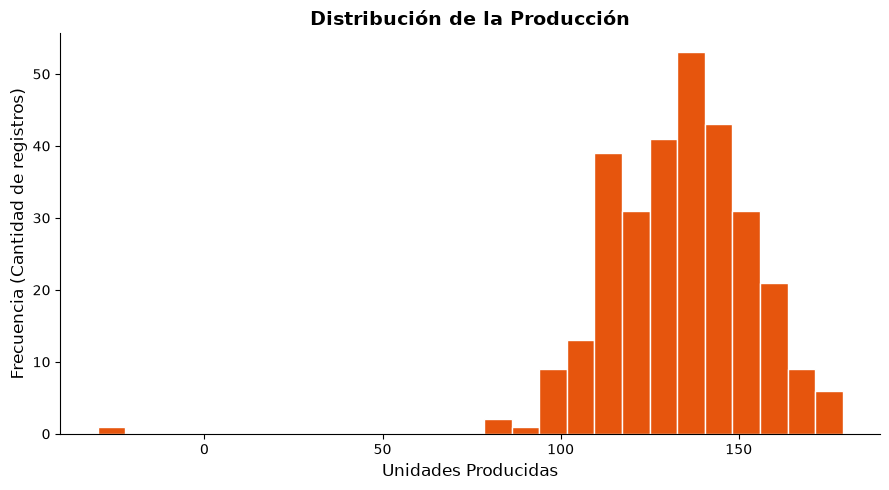

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

# 1. Graficar el histograma usando bins="fd"
ax.hist(df["produccion"], bins="fd", color="#e6550d", edgecolor="white")

# Estética y etiquetas
ax.set_title("Distribución de la Producción", fontsize=14, fontweight="bold")
ax.set_xlabel("Unidades Producidas", fontsize=12)
ax.set_ylabel("Frecuencia (Cantidad de registros)", fontsize=12)

# Limpieza visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 2 y 3. Comentario de observación (Ajusta este texto según lo que veas al correr el gráfico)
"""
OBSERVACIÓN DE LOS DATOS:
- Al observar el histograma, [COMPLETAR: ej. "se nota una forma de campana bastante simétrica centrada alrededor de X unidades, lo que indica una distribución normal"].
- [COMPLETAR: ej. "Sin embargo, se observa una pequeña asimetría hacia la derecha / no se aprecian valores atípicos extremos alejados del bloque principal"].
"""

plt.tight_layout()
plt.show()

## Ejercicio 6 — Bins a prueba

Un compañero de otro equipo te envía un histograma con `bins=3` de la variable `eficiencia` y te dice que "los datos parecen bastante parejos, sin outliers".

Recrea ese histograma con `bins=3`, y después compáralo con el mismo histograma usando `bins="fd"`. ¿Tu compañero tenía razón? Escribe una conclusión corta.

**Pistas:**
- Puedes usar `plt.subplots(1, 2, figsize=(12, 4))` para mostrar los dos histogramas uno al lado del otro y comparar de un vistazo.


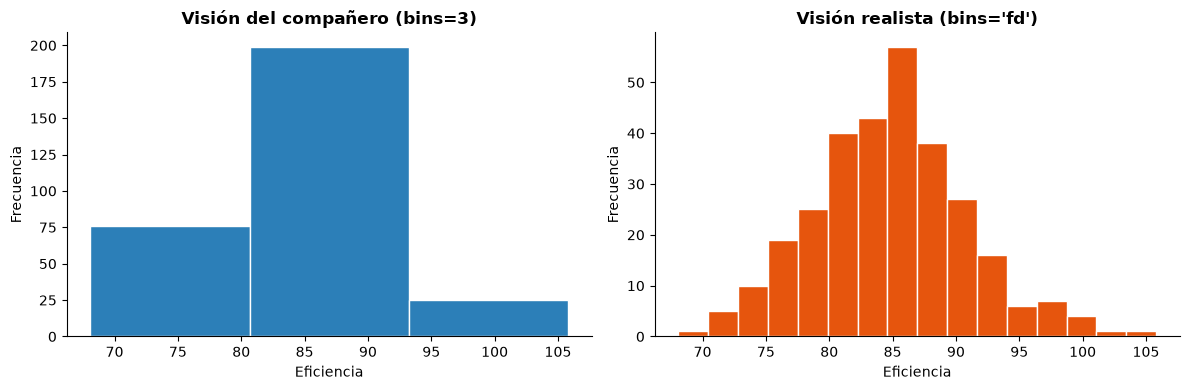

In [12]:
import matplotlib.pyplot as plt

# Crear una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: La versión del compañero (bins=3)
axes[0].hist(df["eficiencia"], bins=3, color="#2c7fb8", edgecolor="white")
axes[0].set_title("Visión del compañero (bins=3)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Eficiencia")
axes[0].set_ylabel("Frecuencia")

# Gráfico 2: La versión realista (bins="fd")
axes[1].hist(df["eficiencia"], bins="fd", color="#e6550d", edgecolor="white")
axes[1].set_title("Visión realista (bins='fd')", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Eficiencia")
axes[1].set_ylabel("Frecuencia")

# Limpieza visual para ambos gráficos
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Ejercicio 7 — ¿La presión depende de la temperatura?

El equipo de ingeniería quiere saber si hay una relación entre temperatura y presión, para ajustar los límites de seguridad de la planta.

1. Haz un scatter de `temperatura` (eje X) contra `presion` (eje Y).
2. A simple vista, ¿te parece que hay una relación lineal, o los puntos están dispersos sin patrón?
3. Marca con un color distinto (puedes graficar ese punto aparte, encima del scatter) el punto que corresponde al sensor defectuoso que encontraste en el Ejercicio 2.

**Pistas:**
- Para resaltar un punto puntual: `ax.scatter(df.loc[15, "temperatura"], df.loc[15, "presion"], color="red", s=100, label="Sensor defectuoso")` (ajusta el índice según lo que encontraste).


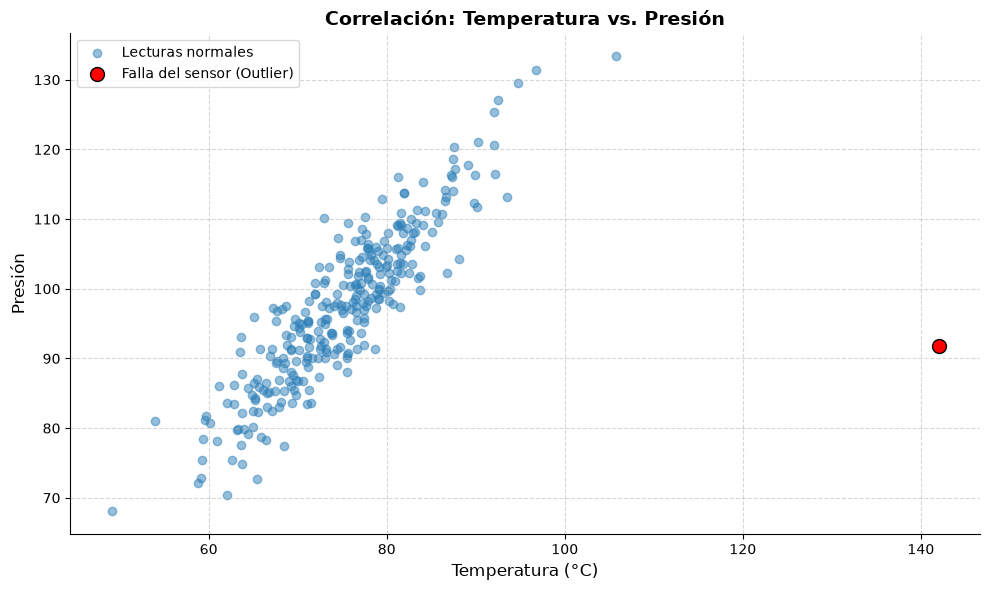

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# 1. Graficar la relación general (Scatter plot principal)
ax.scatter(df["temperatura"], df["presion"], alpha=0.5, color="#2c7fb8", label="Lecturas normales")

# 3. Marcar el punto defectuoso (El "Pico Imposible" que vimos cerca de la hora 15)
# Usamos s=100 para hacer el punto más grande y edgecolor para que resalte
ax.scatter(df.loc[15, "temperatura"], df.loc[15, "presion"], 
           color="red", s=100, edgecolor="black", label="Falla del sensor (Outlier)")

# Estética y etiquetas
ax.set_title("Correlación: Temperatura vs. Presión", fontsize=14, fontweight="bold")
ax.set_xlabel("Temperatura (°C)", fontsize=12)
ax.set_ylabel("Presión", fontsize=12)

# Agregamos la leyenda para que se entienda qué es el punto rojo
ax.legend(loc="upper left")

# Cuadrícula suave para guiar el ojo
ax.grid(True, linestyle="--", alpha=0.5)

# Limpieza visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 2. Conclusión visual (Observación)
"""
OBSERVACIÓN DE LA RELACIÓN:
- Al ver el gráfico general, [COMPLETAR: ej. "se observa una nube de puntos dispersa sin un patrón claro", o "se nota una tendencia lineal positiva donde a mayor temperatura, mayor presión"].
- El punto rojo (outlier) queda totalmente aislado del resto del grupo, confirmando gráficamente que es una lectura anómala que no sigue las reglas físicas del resto del dataset.
"""

plt.tight_layout()
plt.show()


## Ejercicio 8 — Eficiencia según temperatura y consumo, todo junto

El gerente de planta te pide un solo gráfico que muestre, para cada registro: la temperatura, el consumo y la eficiencia — las tres variables a la vez.

Haz un scatter de `temperatura` vs. `consumo_kwh`, coloreando cada punto según su `eficiencia` (con `c=` y una `colorbar`).

**Pistas:**
- `cmap="viridis"` es una buena opción por defecto.
- No olvides `fig.colorbar()` para que se entienda qué representa el color.

---

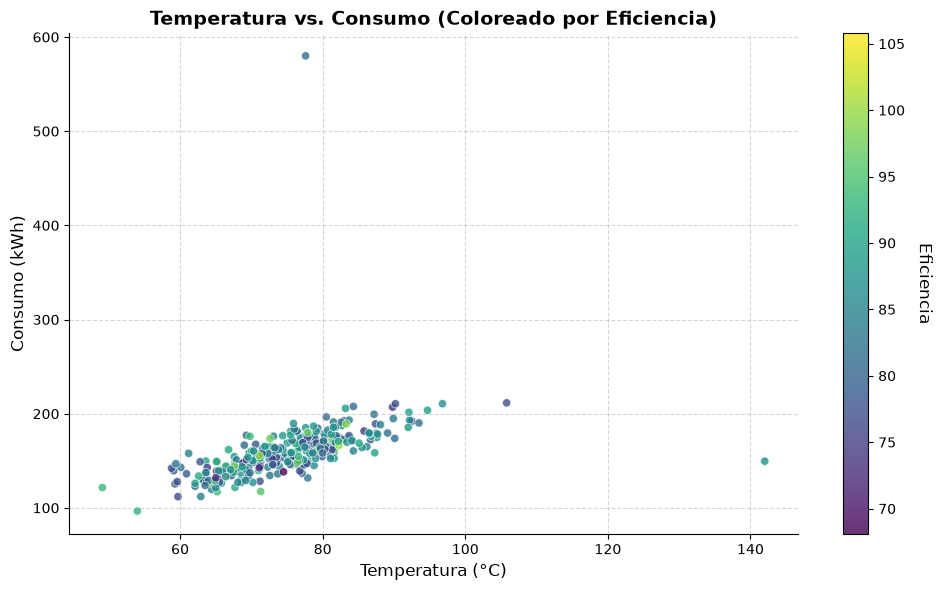

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# 1. Crear el scatter plot multivariable
# x = temperatura, y = consumo_kwh, c = eficiencia (color)
scatter = ax.scatter(df["temperatura"], df["consumo_kwh"], 
                     c=df["eficiencia"], cmap="viridis", 
                     alpha=0.8, edgecolors="white", linewidth=0.5)

# 2. Configurar la barra de color (colorbar)
# Le pasamos el objeto 'scatter' que creamos arriba para que sepa qué escala usar
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Eficiencia", fontsize=12, rotation=270, labelpad=20)

# Estética y etiquetas
ax.set_title("Temperatura vs. Consumo (Coloreado por Eficiencia)", fontsize=14, fontweight="bold")
ax.set_xlabel("Temperatura (°C)", fontsize=12)
ax.set_ylabel("Consumo (kWh)", fontsize=12)

# Cuadrícula y limpieza visual
ax.grid(True, linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Ejercicio 9 — El panorama completo: matriz de correlación

Antes de armar cualquier modelo o reporte más elaborado, es buena práctica mirar cómo se relacionan todas las variables numéricas entre sí.

Crea un mapa de calor con la matriz de correlación de las cinco columnas numéricas del dataset (`temperatura`, `presion`, `consumo_kwh`, `produccion`, `eficiencia`), con los valores numéricos escritos dentro de cada celda.

**Pistas:**
- `df[columnas].corr()`, `ax.imshow()`, `cmap="coolwarm"`, `vmin=-1, vmax=1`.
- Repasa el bloque de "Todo junto" de la clase si te atoras con el `for` que escribe los números en cada celda.

---

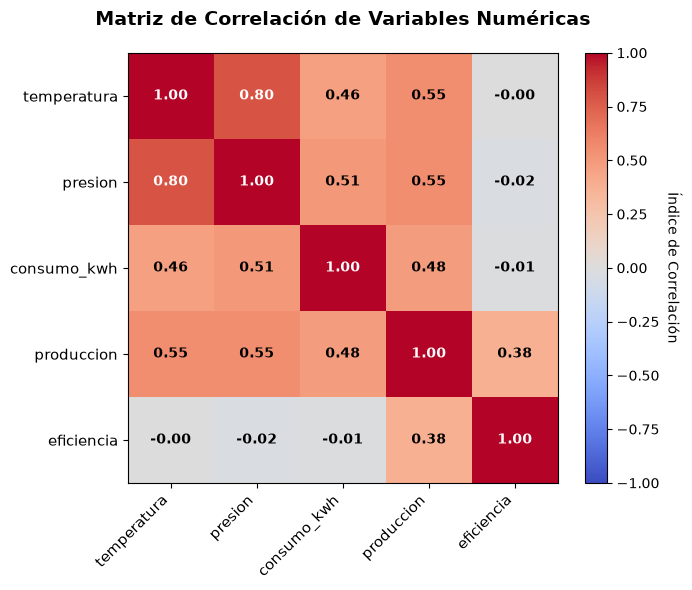

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Seleccionar columnas numéricas y calcular la matriz
columnas_numericas = ["temperatura", "presion", "consumo_kwh", "produccion", "eficiencia"]
matriz_corr = df[columnas_numericas].corr()

# 2. Configurar el gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# 3. Crear el heatmap
im = ax.imshow(matriz_corr, cmap="coolwarm", vmin=-1, vmax=1)

# 4. Configurar los ejes y etiquetas
ax.set_xticks(np.arange(len(columnas_numericas)))
ax.set_yticks(np.arange(len(columnas_numericas)))

# Rotamos las etiquetas del eje X para que no se superpongan
ax.set_xticklabels(columnas_numericas, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(columnas_numericas, fontsize=11)

ax.set_title("Matriz de Correlación de Variables Numéricas", fontsize=14, fontweight="bold", pad=20)

# 5. Agregar la barra de color lateral
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Índice de Correlación", rotation=-90, va="bottom")

# 6. EL TRUCO MAGISTRAL: Anotar los valores dentro de cada celda
for i in range(len(columnas_numericas)):
    for j in range(len(columnas_numericas)):
        # Extraemos el valor exacto de la matriz en esa posición
        valor = matriz_corr.iloc[i, j]
        
        # Elegimos el color del texto: blanco si el fondo es oscuro (valores extremos), negro si es claro (valores cercanos a 0)
        color_texto = "white" if abs(valor) > 0.6 else "black"
        
        # Escribimos el texto centrado
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", color=color_texto, fontweight="bold")

plt.tight_layout()
plt.show()

## Ejercicio 10 — El gráfico tiene que salir bien para la reunión de gerencia (personalización)

Retomando lo que vimos en la clase de personalización: te piden preparar el gráfico de barras del Ejercicio 3 (consumo promedio por turno), pero ahora para mostrarlo en una reunión de gerencia. Debe verse profesional.

Como mínimo, el gráfico final tiene que tener:
- Un título claro y una fuente de tamaño legible para proyectar.
- Colores consistentes (elegí una paleta prolija, no colores por defecto).
- Los valores de cada barra escritos arriba de la barra (con `ax.text()` o `ax.bar_label()`).
- Grilla suave de fondo, sin que compita visualmente con las barras.
- El gráfico guardado como imagen con `plt.savefig("consumo_por_turno.png", dpi=150, bbox_inches="tight")`.


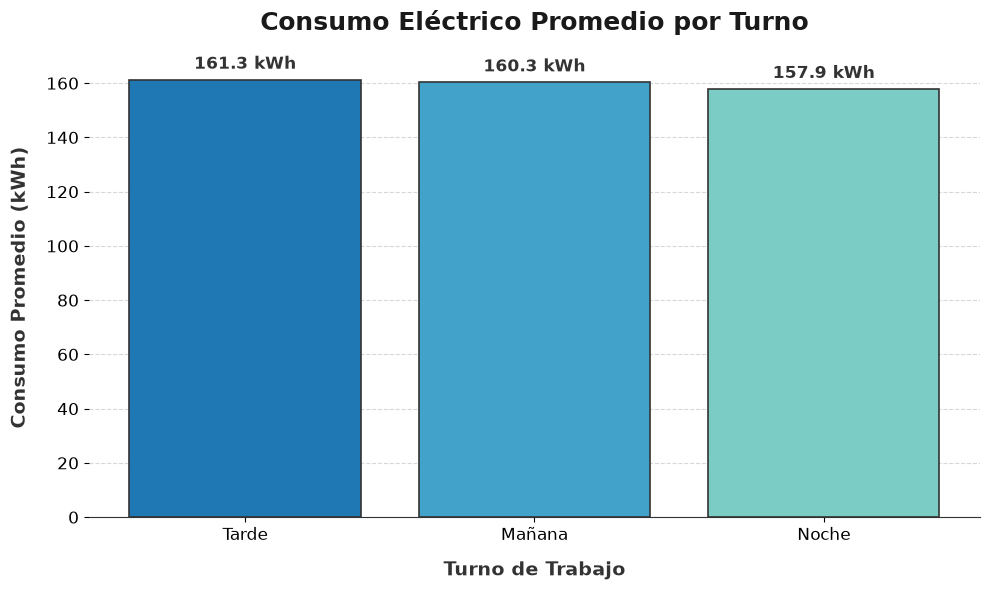

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# (Asumimos que la variable consumo_por_turno ya fue calculada en el Ejercicio 3)
# consumo_por_turno = df.groupby("turno", observed=True)["consumo_kwh"].mean().sort_values(ascending=False)

# 1. Configuración de la figura con un tamaño adecuado para presentación
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Paleta de colores profesional (tonos corporativos coherentes, evitando colores por defecto)
colores_profesionales = ["#1f78b4", "#43a2ca", "#7bccc4"]

# 3. Creación de las barras
barras = ax.bar(consumo_por_turno.index, consumo_por_turno.values, 
                color=colores_profesionales, edgecolor="#333333", linewidth=1.2)

# 4. Título y etiquetas con tamaño de fuente pensado para proyector (legible a distancia)
ax.set_title("Consumo Eléctrico Promedio por Turno", fontsize=18, fontweight="bold", pad=20, color="#1a1a1a")
ax.set_xlabel("Turno de Trabajo", fontsize=14, fontweight="bold", labelpad=12, color="#333333")
ax.set_ylabel("Consumo Promedio (kWh)", fontsize=14, fontweight="bold", labelpad=12, color="#333333")

# Aumentamos el tamaño de las etiquetas de los ejes
ax.tick_params(axis='both', which='major', labelsize=12)

# 5. Valores arriba de cada barra usando bar_label (forma moderna y eficiente en Matplotlib)
ax.bar_label(barras, fmt='%.1f kWh', padding=5, fontsize=12, fontweight="bold", color="#333333")

# 6. Grilla suave de fondo
# set_axisbelow(True) es clave para que la grilla no se dibuje por encima de las barras
ax.set_axisbelow(True) 
ax.grid(axis="y", linestyle="--", alpha=0.5, color="#b3b3b3")

# 7. Limpieza visual (Data-Ink ratio)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False) # Ocultamos el eje Y para confiar en las etiquetas de las barras
ax.spines["bottom"].set_color("#333333")

# 8. Ajuste de márgenes y guardado del archivo en alta calidad
plt.tight_layout()
plt.savefig("consumo_por_turno.png", dpi=150, bbox_inches="tight")

# 9. Mostrar el resultado en pantalla
plt.show()


---

## Ejercicio 11 — Anotar el hallazgo directamente en el gráfico

Encontraste el sensor defectuoso en el Ejercicio 2, pero un gráfico sin explicación no comunica por sí solo. Retoma ese gráfico de líneas de temperatura y agrégale una anotación con flecha señalando el punto inusual, con el texto "Posible falla de sensor".

**Pistas:**
- `ax.annotate("Posible falla de sensor", xy=(15, df.loc[15, "temperatura"]), xytext=(50, 130), arrowprops=dict(facecolor="black", arrowstyle="->"))`
- Ajusta las coordenadas de `xytext` para que el texto no tape la línea

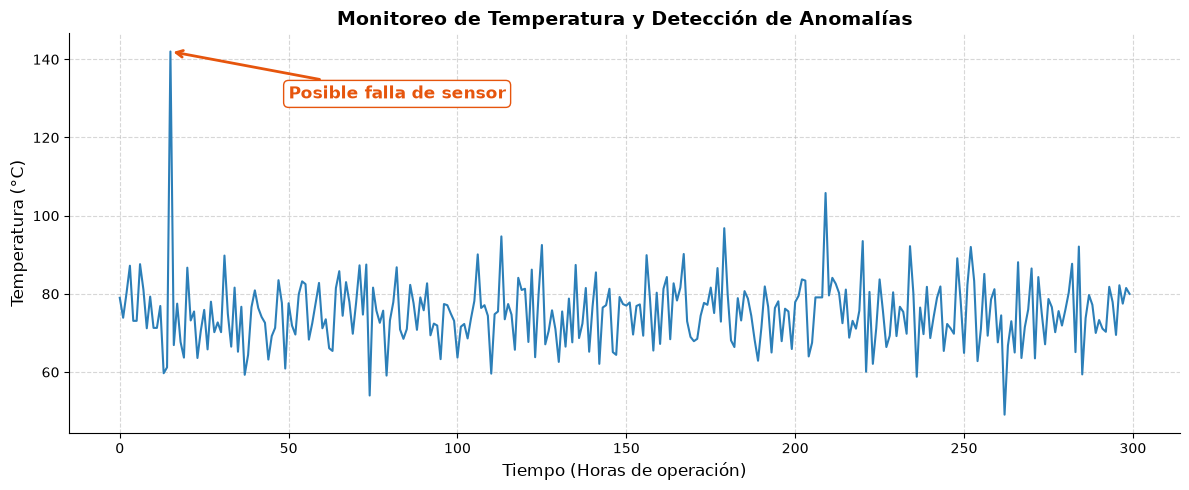

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

# 1. Trazar la línea de temperatura general
ax.plot(df.index, df["temperatura"], color="#2c7fb8", linewidth=1.5)

# 2. Definir las coordenadas del hallazgo (el pico imposible del Ejercicio 2)
# Asumimos que el índice es el 15, ajusta si en tu DataFrame exacto es otro
x_falla = 15
y_falla = df.loc[x_falla, "temperatura"]

# 3. Crear la anotación con flecha
ax.annotate(
    "Posible falla de sensor", 
    xy=(x_falla, y_falla),           # xy: Dónde apunta la punta de la flecha
    xytext=(50, 130),                # xytext: Dónde se ubica el texto
    arrowprops=dict(
        color="#e6550d",             # Color de la flecha
        arrowstyle="->",             # Estilo de flecha simple
        lw=2                         # Grosor de la línea de la flecha
    ),
    fontsize=12, 
    fontweight="bold",
    color="#e6550d",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#e6550d", lw=1) # Agrega un recuadrito al texto
)

# Estética general
ax.set_title("Monitoreo de Temperatura y Detección de Anomalías", fontsize=14, fontweight="bold")
ax.set_xlabel("Tiempo (Horas de operación)", fontsize=12)
ax.set_ylabel("Temperatura (°C)", fontsize=12)

# Cuadrícula suave
ax.grid(True, linestyle="--", alpha=0.5)

# Limpieza de bordes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
